In [1]:
!pwd
!ls

/content
sample_data


In [2]:
!git clone https://github.com/SanuviGamage5043/example_CVIP.git
%cd example_CVIP

Cloning into 'example_CVIP'...
remote: Enumerating objects: 3635, done.
remote: Counting objects: 100% (3635/3635), done.
remote: Compressing objects: 100% (1922/1922), done.
remote: Total 3635 (delta 1714), reused 3626 (delta 1711), pack-reused 0 (from 0)
Receiving objects: 100% (3635/3635), 25.86 MiB | 30.33 MiB/s, done.
Resolving deltas: 100% (1714/1714), done.
/content/example_CVIP


In [3]:
!ls

data  notebooks  README.md  requirements.txt


In [4]:
!pwd

/content/example_CVIP


In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
import random

In [10]:
!mkdir dataset
!mv data/archive/NEU-DET dataset/

In [11]:
!find dataset -maxdepth 3

dataset
dataset/NEU-DET
dataset/NEU-DET/validation
dataset/NEU-DET/validation/images
dataset/NEU-DET/validation/annotations
dataset/NEU-DET/train
dataset/NEU-DET/train/images
dataset/NEU-DET/train/annotations


In [12]:
!rm -r data/archive

In [13]:
!rm -r data

In [47]:
dataset_path = "dataset/NEU-DET"

train_img = os.path.join(dataset_path, "train", "images")
train_ann = os.path.join(dataset_path, "train", "annotations")

val_img = os.path.join(dataset_path, "validation", "images")
val_ann = os.path.join(dataset_path, "validation", "annotations")

print(train_img)
print(val_img)

dataset/NEU-DET/train/images
dataset/NEU-DET/validation/images


In [48]:
def check_folder(path, name):
    print(f"\n=== {name} ===")

    if not os.path.exists(path):
        print("Path not found:", path)
        return

    files = os.listdir(path)
    print("Total files:", len(files))
    print("Sample:", files[:5])

check_folder(train_img, "TRAIN IMAGES")
check_folder(train_ann, "TRAIN ANNOTATIONS")
check_folder(val_img, "VALIDATION IMAGES")
check_folder(val_ann, "VALIDATION ANNOTATIONS")


=== TRAIN IMAGES ===
Total files: 6
Sample: ['pitted_surface', 'crazing', 'inclusion', 'rolled-in_scale', 'patches']

=== TRAIN ANNOTATIONS ===
Total files: 1440
Sample: ['patches_47.xml', 'scratches_141.xml', 'pitted_surface_182.xml', 'inclusion_199.xml', 'inclusion_46.xml']

=== VALIDATION IMAGES ===
Total files: 6
Sample: ['pitted_surface', 'crazing', 'inclusion', 'rolled-in_scale', 'patches']

=== VALIDATION ANNOTATIONS ===
Total files: 360
Sample: ['patches_289.xml', 'pitted_surface_241.xml', 'patches_278.xml', 'patches_244.xml', 'rolled-in_scale_284.xml']


In [49]:
def check_types(folder):
    exts = {}

    for f in os.listdir(folder):
        ext = f.split(".")[-1]
        exts[ext] = exts.get(ext, 0) + 1

    print(exts)

print("TRAIN IMAGE TYPES")
check_types(train_img)

TRAIN IMAGE TYPES
{'pitted_surface': 1, 'crazing': 1, 'inclusion': 1, 'rolled-in_scale': 1, 'patches': 1, 'scratches': 1}


In [50]:
def check_matching(img_folder, ann_folder):
    images = [f.split(".")[0] for f in os.listdir(img_folder)]
    anns = [f.split(".")[0] for f in os.listdir(ann_folder)]

    missing = [img for img in images if img not in anns]

    print("Missing annotations:", len(missing))
    if missing:
        print("Examples:", missing[:5])

check_matching(train_img, train_ann)

Missing annotations: 6
Examples: ['pitted_surface', 'crazing', 'inclusion', 'rolled-in_scale', 'patches']


In [51]:
import os

print("Train folder exists:", os.path.exists(train_img))
print("Sample files:", os.listdir(train_img)[:5])

Train folder exists: True
Sample files: ['pitted_surface', 'crazing', 'inclusion', 'rolled-in_scale', 'patches']


In [52]:
img_name = os.listdir(train_img)[0]
img_path = os.path.join(train_img, img_name)

print("Image path:", img_path)
print("Exists:", os.path.exists(img_path))

Image path: dataset/NEU-DET/train/images/pitted_surface
Exists: True


Train folder: dataset/NEU-DET/train/images
Exists: True
Total images found: 1440
Loading: dataset/NEU-DET/train/images/pitted_surface/pitted_surface_39.jpg


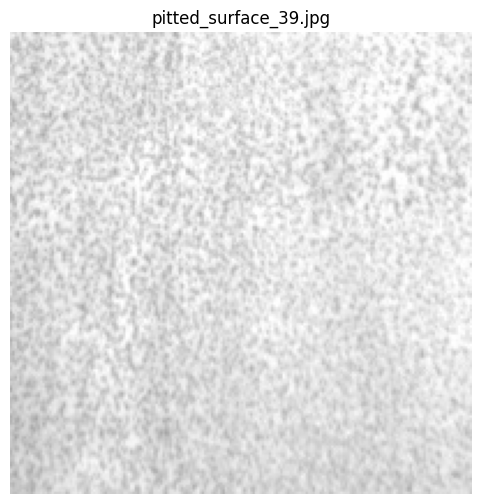

In [53]:
import cv2
import matplotlib.pyplot as plt
import os

# STEP 1: CHECK PATH
print("Train folder:", train_img)
print("Exists:", os.path.exists(train_img))

# STEP 2: FIND ALL IMAGE FILES RECURSIVELY
image_files = []

for root, dirs, files in os.walk(train_img):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Total images found:", len(image_files))

if len(image_files) == 0:
    print("❌ No images found")
else:
    img_path = image_files[0]

    print("Loading:", img_path)

    # STEP 3: READ IMAGE
    img = cv2.imread(img_path)

    if img is None:
        print("❌ OpenCV failed to load image")
        print("Check file format or path:", img_path)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")
        plt.show()

In [54]:
import os
import cv2
import matplotlib.pyplot as plt

# STEP 1: get class folders
class_folders = os.listdir(train_img)

print("Classes found:", class_folders)

Classes found: ['pitted_surface', 'crazing', 'inclusion', 'rolled-in_scale', 'patches', 'scratches']


Loading: dataset/NEU-DET/train/images/pitted_surface/pitted_surface_39.jpg


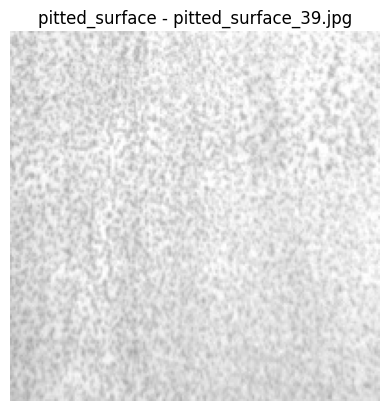

In [55]:
# pick first class folder
class_name = class_folders[0]

class_path = os.path.join(train_img, class_name)

# get images inside it
img_files = os.listdir(class_path)

img_name = img_files[0]
img_path = os.path.join(class_path, img_name)

print("Loading:", img_path)

img = cv2.imread(img_path)

if img is None:
    print("❌ Failed to load image")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"{class_name} - {img_name}")
    plt.axis("off")
    plt.show()

In [57]:
import os

def get_all_images(root_folder):
    image_paths = []

    class_folders = os.listdir(root_folder)

    for cls in class_folders:
        class_path = os.path.join(root_folder, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            if img_name.lower().endswith((".jpg", ".png", ".jpeg")):
                image_paths.append(img_path)

    return image_paths

In [58]:
all_train_images = get_all_images(train_img)

print("Total training images:", len(all_train_images))
print("Sample:", all_train_images[:5])

Total training images: 1440
Sample: ['dataset/NEU-DET/train/images/pitted_surface/pitted_surface_39.jpg', 'dataset/NEU-DET/train/images/pitted_surface/pitted_surface_134.jpg', 'dataset/NEU-DET/train/images/pitted_surface/pitted_surface_168.jpg', 'dataset/NEU-DET/train/images/pitted_surface/pitted_surface_102.jpg', 'dataset/NEU-DET/train/images/pitted_surface/pitted_surface_52.jpg']


In [59]:
import cv2

def load_image(path):
    img = cv2.imread(path)

    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [60]:
def preprocess(img):
    img = cv2.GaussianBlur(img, (5,5), 0)
    img = img.astype(np.float32) / 255.0
    return img

In [61]:
def enhance(img):
    img = (img * 255).astype(np.uint8)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(2.0, (8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    yuv[:,:,0] = cv2.equalizeHist(yuv[:,:,0])
    img = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    return img

In [62]:
def edge_detection(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    canny = cv2.Canny(gray, 100, 200)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, 3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, 3)

    return canny, sobelx, sobely

In [63]:
def morphology(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

    kernel = np.ones((3,3), np.uint8)

    return cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)

In [64]:
def glcm_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    glcm = graycomatrix(gray,
                        distances=[1],
                        angles=[0],
                        symmetric=True,
                        normed=True)

    contrast = graycoprops(glcm, 'contrast')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    return contrast, homogeneity

In [65]:
def cvip_pipeline(img):
    pre = preprocess(img)
    enh = enhance(pre)

    edges, sx, sy = edge_detection(enh)
    morph = morphology(enh)

    glcm = glcm_features(enh)

    return pre, enh, edges, morph, glcm

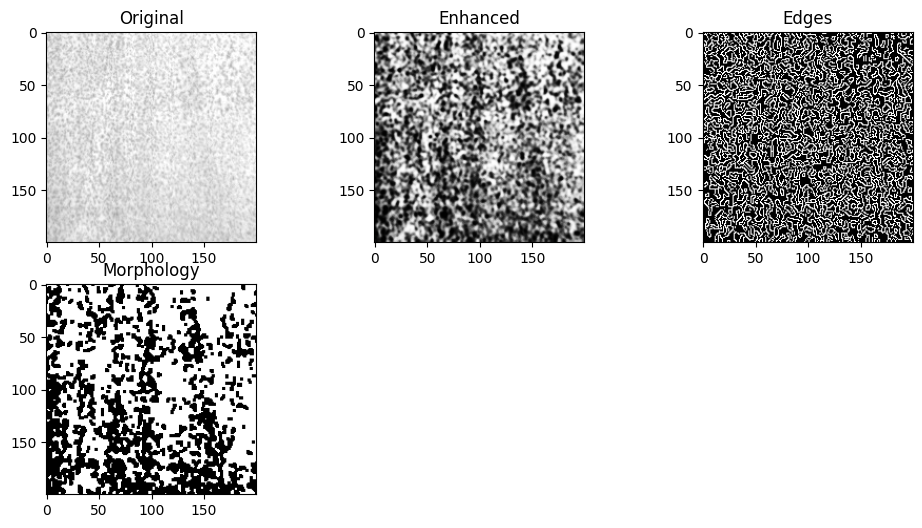

GLCM Features:
Contrast: 1596.7761055276383
Homogeneity: 0.10482734315426226


In [66]:
img = cv2.imread(all_train_images[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pre, enh, edges, morph, glcm = cvip_pipeline(img)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(2,3,2)
plt.imshow(enh)
plt.title("Enhanced")

plt.subplot(2,3,3)
plt.imshow(edges, cmap='gray')
plt.title("Edges")

plt.subplot(2,3,4)
plt.imshow(morph, cmap='gray')
plt.title("Morphology")

plt.show()

print("GLCM Features:")
print("Contrast:", glcm[0])
print("Homogeneity:", glcm[1])

In [67]:
def augment(img):
    img = (img * 255).astype(np.uint8)

    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    if random.random() > 0.5:
        angle = random.randint(-15, 15)
        h,w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2,h//2), angle, 1)
        img = cv2.warpAffine(img, M, (w,h))

    return img

In [68]:
print("Total Training Images:", len(all_train_images))

Total Training Images: 1440


In [69]:
import os

os.makedirs("dataset/NEU-DET-YOLO/images/train", exist_ok=True)
os.makedirs("dataset/NEU-DET-YOLO/images/val", exist_ok=True)

os.makedirs("dataset/NEU-DET-YOLO/labels/train", exist_ok=True)
os.makedirs("dataset/NEU-DET-YOLO/labels/val", exist_ok=True)

print("YOLO folders created")

YOLO folders created


In [72]:
import os

SOURCE_TRAIN = "dataset/NEU-DET/train/images"
SOURCE_VAL   = "dataset/NEU-DET/validation/images"

print("Source train exists:", os.path.exists(SOURCE_TRAIN))
print("Source val exists:", os.path.exists(SOURCE_VAL))

OUTPUT_BASE = "dataset/NEU-DET-YOLO"

train_out = os.path.join(OUTPUT_BASE, "images", "train")
val_out   = os.path.join(OUTPUT_BASE, "images", "val")

os.makedirs(train_out, exist_ok=True)
os.makedirs(val_out, exist_ok=True)

validate_folder(train_path, "TRAIN")
validate_folder(val_path, "VALIDATION")

Source train exists: True
Source val exists: True

===== TRAIN =====
❌ Path not found: ..\dataset\NEU-DET-YOLO/images/train

===== VALIDATION =====
❌ Path not found: ..\dataset\NEU-DET-YOLO/images/val


In [ ]:
def get_all_images(folder):
    image_paths = []

    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.endswith(('.jpg', '.png', '.jpeg')):
                image_paths.append(os.path.join(root, f))

    return image_paths

train_images = get_all_images(SOURCE_TRAIN)
val_images = get_all_images(SOURCE_VAL)

print("Train images:", len(train_images))
print("Val images:", len(val_images))
print("Sample:", train_images[:3])

Train images: 0
Val images: 0
Sample: []


In [ ]:
def process_and_save(image_list, save_folder):

    for path in image_list:

        img = cv2.imread(path)

        if img is None:
            continue

        img = preprocess(img)
        img = augment(img)

        name = os.path.basename(path)

        save_path = os.path.join(save_folder, name)

        cv2.imwrite(save_path, img)

process_and_save(train_images, train_out)
process_and_save(val_images, val_out)

print("Preprocessing completed")

DONE: preprocessing completed


In [ ]:
print("Train output:",
      len(os.listdir("dataset/NEU-DET-YOLO/images/train")))

print("Val output:",
      len(os.listdir("dataset/NEU-DET-YOLO/images/val")))